In [1]:
from cube_datasets import TrainingValueDataset
from cube_nn import CubeValueResNet
from training import train_on_value_dataset
from torch import optim
import matplotlib.pyplot as plt
import torch
from cube import Cube
from solvers import WeightedAStarSolver, RandomSequenceSolver, RestartingWeightedAStarSolver, NoisyWeightedAStarSolver
from cube_nn import NNValueFunctionType
import time

In [2]:
N_MOVES_MAX = 20
N_CUBES_PER_MOVE = 5000

# Create a new net
net = CubeValueResNet()
initial_dataset = TrainingValueDataset.create_balanced(net.get_cube_to_tensor(), N_MOVES_MAX, N_CUBES_PER_MOVE, seed = 1)

optimizer = optim.Adam(net.parameters(), lr=0.001)

losses = []

initial_loss = train_on_value_dataset(net, initial_dataset, optimizer, n_epochs=10)
losses.append(initial_loss)
print(f"Initial loss: {initial_loss}")

i = 0

Single upper bound value dataset not found at datasets/single_upper_bound/single_upper_bound_5_5000_1.pt, generating it...


Saved single upper bound value dataset to datasets/single_upper_bound/single_upper_bound_5_5000_1.pt.


Single upper bound value dataset not found at datasets/single_upper_bound/single_upper_bound_6_5000_1.pt, generating it...


Saved single upper bound value dataset to datasets/single_upper_bound/single_upper_bound_6_5000_1.pt.


Single upper bound value dataset not found at datasets/single_upper_bound/single_upper_bound_7_5000_1.pt, generating it...


...

Single upper bound value dataset not found at datasets/single_upper_bound/single_upper_bound_19_5000_1.pt, generating it...


Saved single upper bound value dataset to datasets/single_upper_bound/single_upper_bound_19_5000_1.pt.


Single upper bound value dataset not found at datasets/single_upper_bound/single_upper_bound_20_5000_1.pt, generating it...


Saved single upper bound value dataset to datasets/single_upper_bound/single_upper_bound_20_5000_1.pt.


Initial loss: 135.56724329993838


In [2]:
# Load a previously saved net
i = 6800
net = CubeValueResNet()
net.load_state_dict(torch.load(f'temp_models/resnet2/cube_value_resnet_iter_{i}.pth'))

optimizer = optim.Adam(net.parameters(), lr=0.001)

losses = torch.load(f'temp_models/resnet2/losses_list_{i}.pth')

In [8]:
N_CUBES_PER_MOVE = 1000
N_MOVES_MAX = 20
N_MOVES_DIFFERENCE_MAX = 3
N_EPOCHS = 5
SIMILAR_EXTENSION_FRACTION = None

# set the STANDARD value function for speed
net.set_value_function_type(NNValueFunctionType.STANDARD)

for j in range(200):
    i += 1
    new_dataset = TrainingValueDataset.create_from_bellman_equation(net, N_MOVES_MAX, N_CUBES_PER_MOVE, n_moves_difference_max=N_MOVES_DIFFERENCE_MAX, similar_cubes_extension=SIMILAR_EXTENSION_FRACTION)
    loss = train_on_value_dataset(net, new_dataset, optimizer, n_epochs=N_EPOCHS)
    losses.append(loss)
    print(f"Iteration {i+1}, loss: {loss}")

    # Save the model and plot of losses every 10 iterations
    if (i + 1) % 10 == 0:
        torch.save(net.state_dict(), f'temp_models/resnet2/cube_value_resnet_iter_{i+1}.pth')
        torch.save(losses, f'temp_models/resnet2/losses_list_{i+1}.pth')
        plt.plot(losses[1:]) # Skip initial loss for better visualization
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Iterations')
        plt.savefig(f'figs/resnet2/loss_plot_iter_{i+1}.png')
        plt.clf()

Iteration 6802, loss: 1.9900878859417779


Iteration 6803, loss: 1.9802181238219851


Iteration 6804, loss: 1.9541573899132865


Iteration 6805, loss: 1.9063524981339772


Iteration 6806, loss: 1.9975903366293226


...

Iteration 6997, loss: 1.947018779317538


Iteration 6998, loss: 1.8971593580075672


Iteration 6999, loss: 1.9403089933452151


Iteration 7000, loss: 1.9882642015105203


Iteration 7001, loss: 1.8881712686447871


<Figure size 640x480 with 0 Axes>

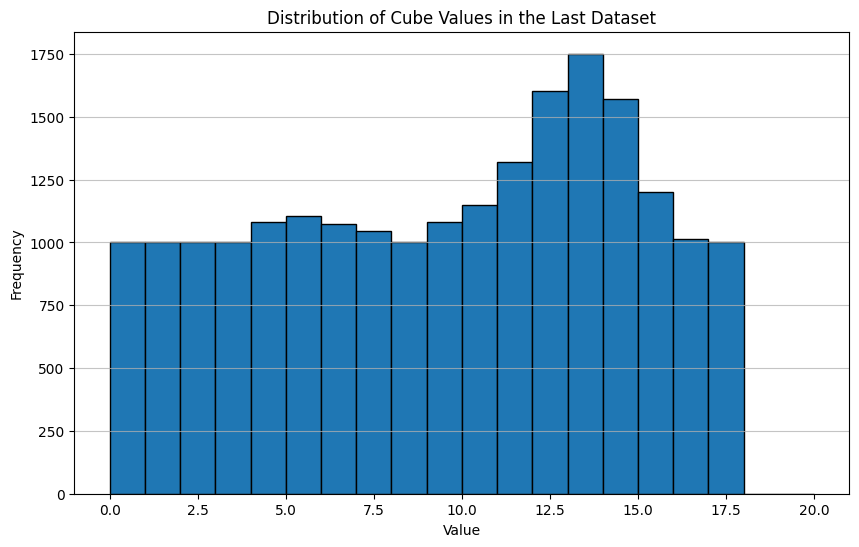

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

# plot the distribution of values in the last dataset
values = [value.item() for _, value in new_dataset]
fig = plt.figure(figsize=(10, 6))
plt.hist(values, bins=range(N_MOVES_MAX+1), edgecolor='black')

plt.title('Distribution of Cube Values in the Last Dataset')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.savefig(f'value_distribution.png')

In [3]:
net.set_value_function_type(NNValueFunctionType.STANDARD)
solver = WeightedAStarSolver(net.as_value_function(), weight=0.15, max_moves=50, max_queue_size=100000)

In [6]:
net.set_value_function_type(NNValueFunctionType.STANDARD)
solver = NoisyWeightedAStarSolver(net.as_value_function(), weight=0.15, noise=0.5, max_moves=50, max_queue_size=100000)

In [5]:
net.set_value_function_type(NNValueFunctionType.STANDARD)
# solver = RestartingWeightedAStarSolver(net.as_value_function(), weight=0.15, max_moves=50, max_queue_size=100000)
solver = RestartingWeightedAStarSolver(net.as_value_function(), weight=0.15, max_moves=40, max_queue_size=100000, t_max_per_attempt=6, max_restarts=9)

In [30]:
net.set_value_function_type(NNValueFunctionType.STANDARD)
solver = RandomSequenceSolver(net.as_value_function(), sequence_length=4, max_sequences=2000)

Loaded full optimal value dataset from datasets/full/full_4.pt.


In [4]:
N = 10
# eval_cubes = [
#     Cube(n_scramble_moves=5),
#     Cube(n_scramble_moves=8),
#     Cube(n_scramble_moves=10),
#     Cube(n_scramble_moves=12),
#     Cube(n_scramble_moves=15),
#     Cube(n_scramble_moves=20),
# ]

eval_cubes = [Cube(n_scramble_moves=40) for _ in range(N)]


In [7]:
solved = 0
for cube in eval_cubes:
    t0 = time.time()
    solution = solver(cube)
    t1 = time.time()
    if solution is None:
        print("No solution found")
    else:
        print(f"Solution found in {len(solution)} moves: {solution}, time taken: {t1 - t0:.2f} seconds")
        solved = solved + 1

print(f"Total number of solved cubes: {solved}")

No solution found
Solution found in 41 moves: [U, F, R, D, B', U, R', L2, U', B, D', U2, R, F, D2, F2, D', U', R2, U, F, U2, R, U, R, D, R, U2, B2, D2, L2, D2, B, D, F', D', B2, D, F, D', B'], time taken: 5.81 seconds
Solution found in 36 moves: [R, B', D2, F', L2, U', D', R2, D', U2, R, B2, U', B', D', B', F2, U, B2, U, D, L, F2, R', L, D2, R', D', U2, L, D', L', U2, L, D, L'], time taken: 7.52 seconds
Solution found in 32 moves: [U2, B', R2, B', L', B, U, R2, F, D2, F', U2, L2, F', L, D2, R, F, L', F, U2, R, U2, R', B', D, B, U2, B', D', B, U2], time taken: 3.31 seconds
No solution found
Solution found in 45 moves: [R2, B', D', L, D, L', D, U', D, F, D', L', D', U2, L, D, R', F', U', R2, F2, L2, F, D2, B2, U2, R, U2, B2, D, L2, F2, D', L2, D, B2, U', F2, B2, U', F2, U, B2, U', F2], time taken: 28.46 seconds
Solution found in 34 moves: [F2, L, R, U2, F', R, F, R, F2, R2, F', D2, B2, U, L, F, R', U, R2, U, F', B, U, L, U', L', U2, F', U, B, U', F, U, B'], time taken: 7.30 seconds
Solut

In [21]:

stats = {}

# evaluate all value function types
for value_function_type in NNValueFunctionType:
    net.set_value_function_type(value_function_type)
    solver = WeightedAStarSolver(net.as_value_function(), weight=0.1, max_moves=50, max_queue_size=100000, t_max=60)

    solved = 0
    lens = []
    times = []
    for cube in eval_cubes:
        t0 = time.time()
        solution = solver(cube)
        t1 = time.time()
        if solution is None:
            print(f"No solution found with value function type {value_function_type}")
        else:
            print(f"Solution found with value function type {value_function_type} in {len(solution)} moves: {solution}, time taken: {t1 - t0:.2f} seconds")
            solved = solved + 1
        lens.append(len(solution) if solution is not None else 0)
        times.append(t1 - t0)

    stats[value_function_type] = (solved, lens, times)

    print(f"Total number of solved cubes with value function type {value_function_type}: {solved}")


print("Summary of results:")
for value_function_type, (solved, lens, times) in stats.items():
    print(f"Value function type: {value_function_type}")
    print(f"  Solved: {solved}/{N}")
    print(f"  Solution lengths: {lens}")
    print(f"  Times: {[f'{t:.2f}' for t in times]}")
    print()
        

No solution found with value function type NNValueFunctionType.STANDARD
Solution found with value function type NNValueFunctionType.STANDARD in 39 moves: [F, L', D, U', R', D2, F, D', F', R, U, F', R, D, B', U', B', R', B, R, B, R', F', D', F2, U, D', F', D', L, D, L, D, L2, B2, R2, U, R2, B2], time taken: 7.54 seconds
Solution found with value function type NNValueFunctionType.STANDARD in 48 moves: [F, L, U', B', U2, R', U2, D, F2, U2, F2, B, D2, L2, F', R, F', R', F, R, U, R2, D2, F, L2, F', U, D', B2, D2, B', U', B, D2, B2, D', F2, B2, U2, R2, U', R2, B2, U', F2, U, B2, U'], time taken: 2.77 seconds
Solution found with value function type NNValueFunctionType.STANDARD in 48 moves: [D2, R', F, L2, B2, U2, B2, R2, U2, D', R, B', L', B2, L2, F2, D', R', B, U', R, B2, R', L', U2, F', R2, F, U2, R2, U2, R', U2, R', U2, L', B', R', B, R, B', U2, L2, D2, F', R2, D2, L2], time taken: 30.22 seconds
Solution found with value function type NNValueFunctionType.STANDARD in 42 moves: [D, U, B, F',

In [50]:

stats = {}

weights = [0.12, 0.18]

# evaluate all value function types
for j, weight in enumerate(weights):
    net.set_value_function_type(NNValueFunctionType.STANDARD)
    solver = WeightedAStarSolver(net.as_value_function(), weight=weight, max_moves=50, max_queue_size=100000, t_max=60)

    solved = 0
    lens = []
    times = []
    for cube in eval_cubes:
        t0 = time.time()
        solution = solver(cube)
        t1 = time.time()
        if solution is None:
            print(f"No solution found with weight {weight}")
        else:
            print(f"Solution found with weight {weight} in {len(solution)} moves: {solution}, time taken: {t1 - t0:.2f} seconds")
            solved = solved + 1
        lens.append(len(solution) if solution is not None else 0)
        times.append(t1 - t0)

    stats[j] = (solved, lens, times)

    print(f"Total number of solved cubes with weight {weight}: {solved}")


print("Summary of results:")
for j, (solved, lens, times) in stats.items():
    print(f"Weight: {weights[j]}")
    print(f"  Solved: {solved}/{N}")
    print(f"  Solution lengths: {lens}")
    print(f"  Times: {[f'{t:.2f}' for t in times]}")
    print()
        

Solution found with weight 0.12 in 47 moves: [F', B2, L2, D2, U, L', R', U', F, L, F', D, F', D2, F2, D2, B', R2, F2, D, R, F', D2, F', R2, L, D2, R', B2, R, B2, L, F, L, F', R2, F2, L2, U2, L, F2, L2, B2, R', D2, R, B2], time taken: 12.69 seconds
Solution found with weight 0.12 in 39 moves: [R, B2, D, L2, U', F, U', B', D2, F', L2, R', D2, F', R, U', R', U2, R', F, R', B', D, R, D, B, U2, B2, U2, F2, B, L, B2, R, L', D2, R', B', D2], time taken: 32.54 seconds
Solution found with weight 0.12 in 36 moves: [F2, B2, D', R, B, L', U', D, R, D', L2, F', D2, L2, F', U, R, F, U', F2, U', F2, U, L', R2, F, R2, F', U2, R, D, R', U2, R, D', R'], time taken: 4.92 seconds
Solution found with weight 0.12 in 46 moves: [D', U, R, U2, B', R2, D2, R2, D2, F, L2, F', R, F2, L', F', R', D, U', B, F2, U, F2, L2, F', B', D2, F, D2, U2, R2, U2, B', R2, B, R2, F', U2, F, L, D', L', U2, L, D, L'], time taken: 20.20 seconds
Solution found with weight 0.12 in 34 moves: [R, B, R, B', D2, U, D', L', U2, L2, B', L

<Figure size 640x480 with 0 Axes>

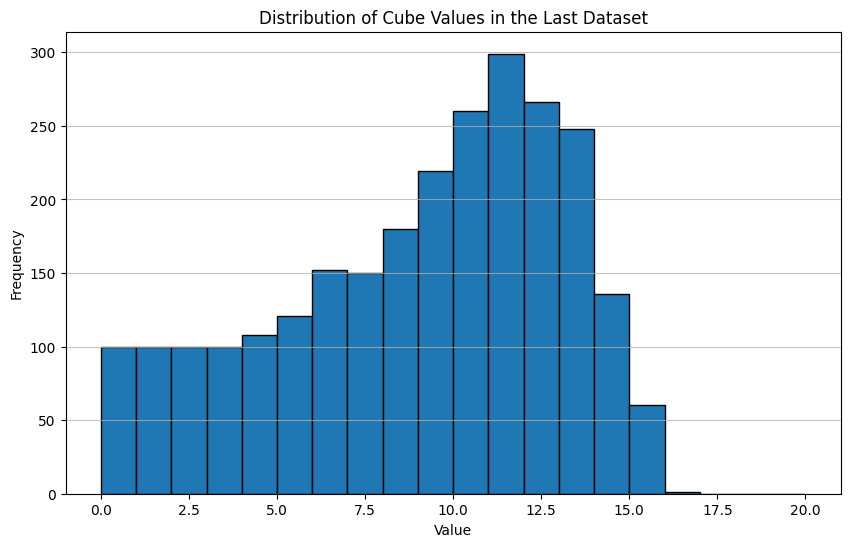

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

new_dataset = TrainingValueDataset.create_from_bellman_equation(net, 25, 100)
# plot the distribution of values in the last dataset
values = [value.item() for _, value in new_dataset]
fig = plt.figure(figsize=(10, 6))
plt.hist(values, bins=range(N_MOVES_MAX+1), edgecolor='black')

plt.title('Distribution of Cube Values in the Last Dataset')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.savefig(f'value_distribution.png')


(array([ 2.,  0.,  4.,  5.,  6., 20., 13., 30., 25., 28., 38., 25., 26.,
        39., 46., 36., 52., 46., 27., 29., 30., 43., 36., 43., 46., 27.,
        31., 32., 27., 20., 21., 27., 17., 28., 17., 11.,  6.,  9., 12.,
         5.,  5.,  3.,  4.,  0.,  0.,  1.,  1.,  0.,  0.,  1.]),
 array([0.80342484, 0.95157616, 1.09972748, 1.2478788 , 1.39603012,
        1.54418144, 1.69233276, 1.84048409, 1.98863541, 2.13678673,
        2.28493805, 2.43308937, 2.58124069, 2.72939201, 2.87754333,
        3.02569466, 3.17384598, 3.3219973 , 3.47014862, 3.61829994,
        3.76645126, 3.91460258, 4.06275391, 4.21090523, 4.35905655,
        4.50720787, 4.65535919, 4.80351051, 4.95166183, 5.09981316,
        5.24796448, 5.3961158 , 5.54426712, 5.69241844, 5.84056976,
        5.98872108, 6.13687241, 6.28502373, 6.43317505, 6.58132637,
        6.72947769, 6.87762901, 7.02578033, 7.17393166, 7.32208298,
        7.4702343 , 7.61838562, 7.76653694, 7.91468826, 8.06283958,
        8.21099091]),
 <BarContainer

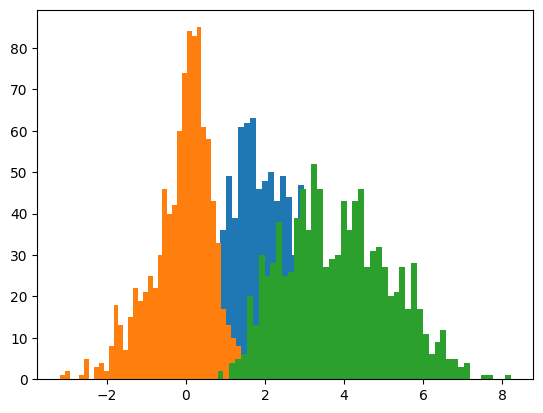

In [18]:
import numpy as np

val_fn = net.as_value_function()

N = 1000
vals = np.zeros((N, 4)) # current, min neighbor, mean neighbor, max neighbor
for i in range(N):
    cube = Cube(n_scramble_moves=20)
    val = val_fn(cube)
    
    neighbor_cubes = cube.get_all_neighbors()
    neighbor_values = val_fn(neighbor_cubes)
    
    vals[i, 0] = val
    vals[i, 1] = neighbor_values.min()
    vals[i, 2] = neighbor_values.mean()
    vals[i, 3] = neighbor_values.max()

diff_val = vals[:, 0] - vals[:, 1]
plt.hist(diff_val, bins=50)

diff_avg = vals[:, 0] - vals[:, 2]
plt.hist(diff_avg, bins=50)

diff_max = vals[:, 3] - vals[:, 1]
plt.hist(diff_max, bins=50)

(array([ 2.,  0.,  1.,  0.,  1.,  5.,  1.,  4.,  2.,  5.,  8.,  9., 16.,
        17., 16., 18., 19., 21., 24., 17., 32., 29., 35., 33., 35., 42.,
        41., 33., 33., 31., 34., 38., 35., 36., 40., 34., 39., 23., 34.,
        32., 25., 24., 20., 13., 15., 10.,  7.,  9.,  1.,  1.]),
 array([ 6.5621891 ,  6.7354063 ,  6.9086235 ,  7.08184071,  7.25505791,
         7.42827511,  7.60149231,  7.77470951,  7.94792671,  8.12114391,
         8.29436111,  8.46757832,  8.64079552,  8.81401272,  8.98722992,
         9.16044712,  9.33366432,  9.50688152,  9.68009872,  9.85331593,
        10.02653313, 10.19975033, 10.37296753, 10.54618473, 10.71940193,
        10.89261913, 11.06583633, 11.23905354, 11.41227074, 11.58548794,
        11.75870514, 11.93192234, 12.10513954, 12.27835674, 12.45157394,
        12.62479115, 12.79800835, 12.97122555, 13.14444275, 13.31765995,
        13.49087715, 13.66409435, 13.83731155, 14.01052876, 14.18374596,
        14.35696316, 14.53018036, 14.70339756, 14.87661476,

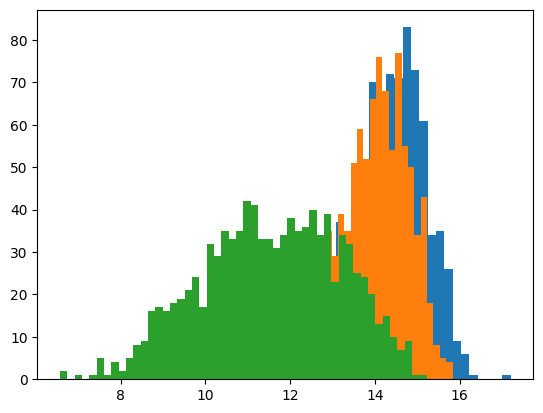

In [20]:
plt.hist(vals[:, 0], bins=50)
plt.hist(vals[:, 2], bins=50)
plt.hist(vals[:, 1], bins=50)
